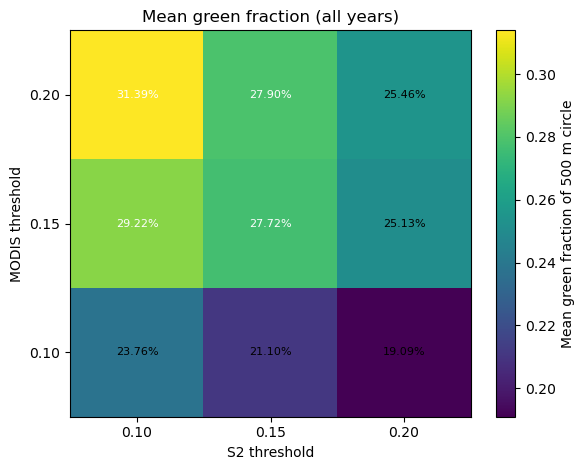

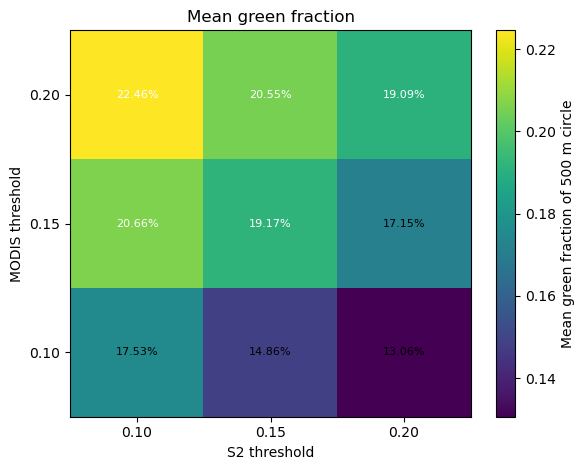

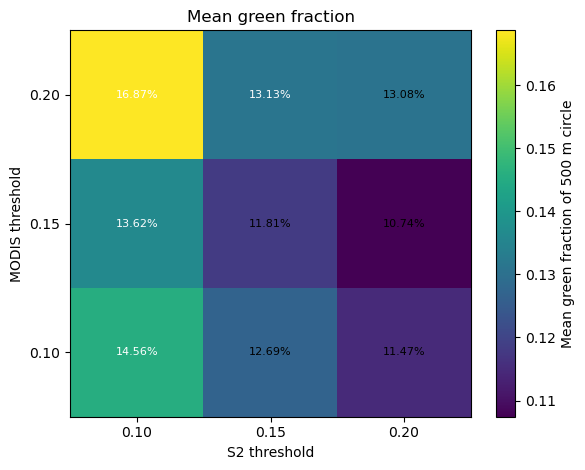

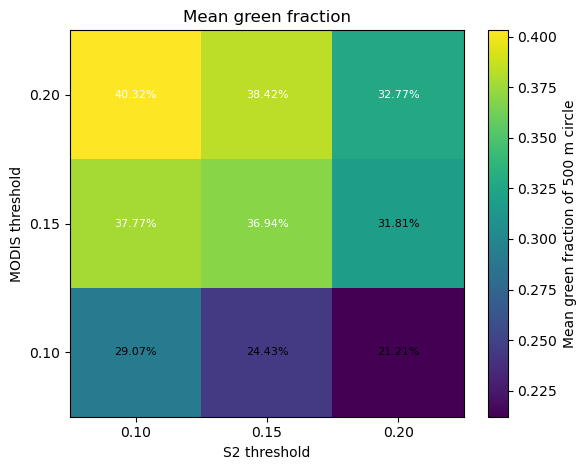

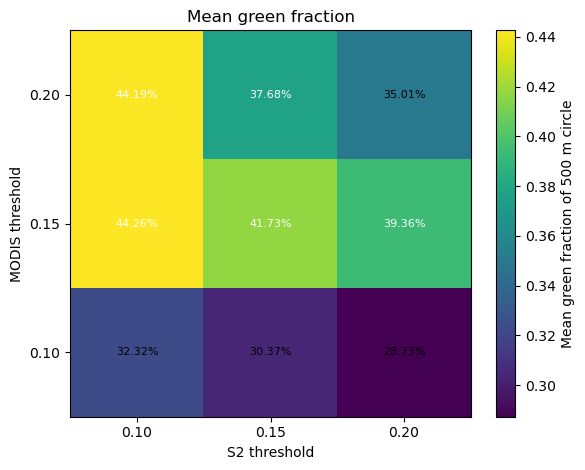

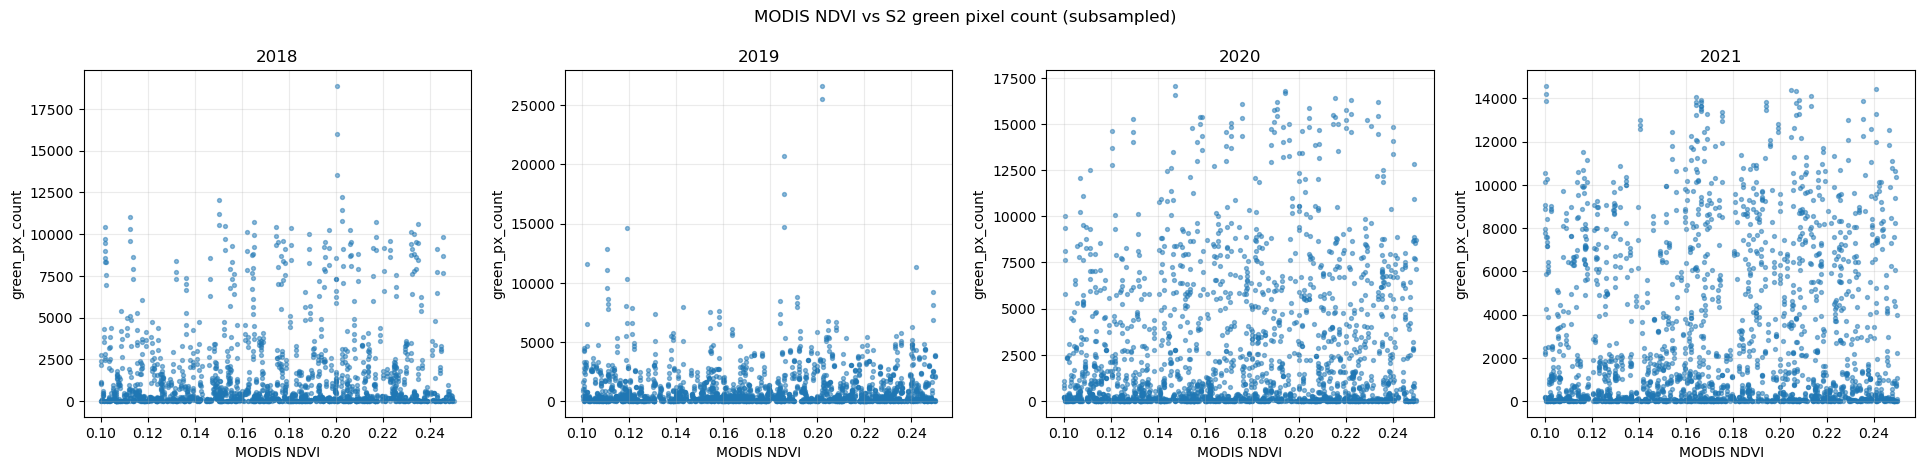

In [32]:
# -*- coding: utf-8 -*-
"""
Visualize threshold-grid results (ONLY heatmap + scatter) with plt.show().

It expects CSVs named like:
  S2_green_pixel_count_2018_2021_MODIS0.10_S20.15.csv
Columns inside each CSV:
  ['year','row','col','lon','lat','modis_ndvi','s2_has_data','green_px_count','modis_thr','s2_thr']

Two figures are shown (not saved):
  1) Heatmap of mean green fraction (overall + per-year)
  2) Scatter of MODIS NDVI vs green_px_count (faceted by year)

Author: you
"""

from pathlib import Path
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================== USER CONFIG ==================
OUT_DIR = r"G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\threshold_grid_outputs_250"
BUFFER_M = 500       # must match your EE runner (circle radius in meters)
S2_RES_M = 10        # Sentinel-2 NDVI band resolution (meters)
MAX_POINTS_SCATTER = 10000  # subsample for scatter clarity/speed

# ============== Derived constants ================
PIXELS_IN_CIRCLE = math.pi * (BUFFER_M**2) / (S2_RES_M**2)  # ~7854
PAIR_NAME_FMT = "M{m:.2f}-S{s:.2f}"

# ================== Helpers ======================
def _parse_pair_from_fname(fname: str):
    """
    Parse MODIS and S2 thresholds from filename tail.
    Accepts ..._MODIS0.10_S20.15.csv etc.
    """
    m = re.search(r"_MODIS([0-9]*\.?[0-9]+)_S2([0-9]*\.?[0-9]+)\.csv$", fname)
    if not m:
        return None, None
    return float(m.group(1)), float(m.group(2))

def load_all_csvs(out_dir: str) -> pd.DataFrame:
    files = list(Path(out_dir).glob("S2_green_pixel_count_*_MODIS*_S2*.csv"))
    if not files:
        raise FileNotFoundError(f"No threshold CSVs found in: {out_dir}")

    dfs = []
    for f in files:
        modis_thr, s2_thr = _parse_pair_from_fname(f.name)
        if modis_thr is None:
            print(f"Skip unrecognized file name: {f}")
            continue

        df = pd.read_csv(f)

        # Ensure thresholds exist as columns
        if "modis_thr" not in df.columns:
            df["modis_thr"] = modis_thr
        if "s2_thr" not in df.columns:
            df["s2_thr"] = s2_thr

        # Clean and compute derived fields
        df["green_px_count"] = df["green_px_count"].clip(lower=0).astype(int)
        df["modis_ndvi"] = df["modis_ndvi"].clip(0, 1)
        df["pair"] = [PAIR_NAME_FMT.format(m=df.iloc[i]["modis_thr"], s=df.iloc[i]["s2_thr"]) for i in range(len(df))]
        df["green_fraction_circle"] = df["green_px_count"] / PIXELS_IN_CIRCLE

        dfs.append(df)

    big = pd.concat(dfs, ignore_index=True)
    return big

def pair_order(df: pd.DataFrame):
    """
    Sort threshold combos for consistent display:
    MODIS thr descending (rows top→bottom), S2 thr ascending (cols left→right).
    """
    tmp = (df[["pair","modis_thr","s2_thr"]]
           .drop_duplicates()
           .sort_values(by=["modis_thr","s2_thr"], ascending=[False, True]))
    return tmp["pair"].tolist()

# ================== Plots (SHOW only) ==================
def plot_heatmaps_fraction(df: pd.DataFrame):
    """
    Heatmaps of mean green fraction per (modis_thr, s2_thr).
    Shows one overall heatmap and then per-year heatmaps, each with plt.show().
    """
    def _heat(df_sub: pd.DataFrame, title: str):
        tbl = (df_sub.groupby(["modis_thr","s2_thr"])["green_fraction_circle"]
               .mean().reset_index())
        if tbl.empty:
            print("No data to plot for:", title)
            return
        piv = tbl.pivot(index="modis_thr", columns="s2_thr", values="green_fraction_circle")
        # Arrange axes: MODIS high at top, S2 ascending left→right
        piv = piv.sort_index(ascending=False)
        piv = piv.reindex(sorted(piv.columns), axis=1)

        plt.figure(figsize=(6, 4.8))
        im = plt.imshow(piv.values, aspect="auto")
        plt.colorbar(im, label="Mean green fraction of 500 m circle")
        plt.xticks(range(len(piv.columns)), [f"{v:.2f}" for v in piv.columns], rotation=0)
        plt.yticks(range(len(piv.index)), [f"{v:.2f}" for v in piv.index])
        plt.xlabel("S2 threshold")
        plt.ylabel("MODIS threshold")
        plt.title(title)

        # Annotate cells with percentages
        avg = np.nanmean(piv.values)
        for i in range(piv.shape[0]):
            for j in range(piv.shape[1]):
                val = piv.values[i, j]
                if np.isfinite(val):
                    # simple contrast: white text if above average, else black
                    color = "white" if val > avg else "black"
                    plt.text(j, i, f"{val:.2%}", ha="center", va="center", fontsize=8, color=color)

        plt.tight_layout()
        plt.show()

    # Overall
    _heat(df, "Mean green fraction (all years)")

    # Per year
    for y in sorted(df["year"].unique()):
        _heat(df[df["year"] == y], f"Mean green fraction")

def plot_scatter_modis_vs_green(df: pd.DataFrame, max_points: int = MAX_POINTS_SCATTER):
    """
    Scatter of MODIS NDVI vs green_px_count, faceted by year, using plt.show().
    Subsamples to max_points for readability.
    """
    # Subsample for speed/clarity
    if len(df) > max_points:
        df_plot = df.sample(max_points, random_state=0)
    else:
        df_plot = df.copy()

    years = sorted(df_plot["year"].unique())
    ncols = min(4, len(years))
    nrows = int(np.ceil(len(years) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(4.6*ncols+1, 4.2*nrows+0.5),
                             squeeze=False)
    for i, y in enumerate(years):
        r, c = divmod(i, ncols)
        ax = axes[r][c]
        sel = df_plot["year"] == y
        ax.scatter(df_plot.loc[sel, "modis_ndvi"],
                   df_plot.loc[sel, "green_px_count"],
                   s=8, alpha=0.5)
        ax.set_title(str(y))
        ax.set_xlabel("MODIS NDVI")
        ax.set_ylabel("green_px_count")
        ax.grid(True, alpha=0.25)

    # Hide any empty subplots
    for k in range(len(years), nrows*ncols):
        r, c = divmod(k, ncols)
        axes[r][c].axis("off")

    fig.suptitle("MODIS NDVI vs S2 green pixel count (subsampled)", y=0.99)
    plt.tight_layout()
    plt.show()

# ================== Main ===========================
if __name__ == "__main__":
    df = load_all_csvs(OUT_DIR)
    # --- Only these two figures, shown on screen (no saving) ---A
    plot_heatmaps_fraction(df)
    plot_scatter_modis_vs_green(df)